# D-PILOT-E — Evidence Slot Dependency Matrix

| field | value |
|---|---|
| research_question | Axis A(KWCAG) · Axis B(depth) · Axis C(obstruction) 이 공유하는 raw evidence slot 은 무엇이며, 그 공유가 planned association 에서 correlated measurement error 를 만들 수 있는 pair 는 어디인가 |
| rq_id | `RQ-D-PILOT-001` |
| child_id | `D-PILOT-E` |
| hypothesis_id | `H-PILOT-E-SLOT-DEPENDENCY` |
| competing_hypothesis | 축이 측정 공정에서 독립이다 / 일부 pair 만 공유 / 광범위 공유로 독립 전제 불성립 |
| **old input snapshot sha** | `D_OBSERVATION_TABLE_v2.csv` = `c39c10f09f7a6a7603409550eb331612eb44634eb98ec387a604aa5221351e6b`<br>`fact_landing_observation.json` = `4ed58b66e002d25ce324efa720462bef45dec2826b68ab7babbb3335cb06fa8c`<br>`fact_interrupt_element.json` = `caebf1a4344a0b96d793b2f14418c14ece7c3ebef788e8eb7033eb678093dbf6`<br>`fact_task_entry.json` = `61bb7051045ab27ddc5b8105728b64c3f0df1c69c3f278d14087789fbcad0064`<br>`fact_criterion_result.json` = `4f53cda18c2baa0c0354bb5f9a3ecbe5ed12ab4d8e11ba873c2f11161202b945` (0행)<br>`SSOTV2/00_SSOT_v2.1...md` = `1a4f6e75ccf70b2eaeddcad43c27c2cb5b3c93db1520760aa1850c63524a4ea3` |
| input_snapshot_sha_NEW | `NOT_APPLICABLE_frozen_only` — 새 pilot capture 는 아직 존재하지 않는다 |
| code sha (읽기 전용) | `2281c853950d0c475c5d2c1678680b971c2804f4` |
| MLflow run_id | `5f34b7743437412b9e18f7026422a3f2` (experiment `LA_04_DIAGNOSTIC_PILOT_RESEARCH`, parent `27d10a01df5442b681ee73062e01c123`) |
| n | 56 target (in_mart==1) · 54 with probe · 235 interrupt row · 166 overlay reaching text-rule branch · 854 hittable activation candidate |
| grain | raw evidence slot × axis (정성) / target (in_mart==1) / visible overlay candidate / hittable primary_action_candidate |
| seed | `20260827` |
| **axis_a_status** | `"0_rows_proxy_only"` — `fact_criterion_result` 0행, @SHA engine 에 KWCAG evaluator 모듈 부재. Axis A 는 **proxy 로만** 다룬다. |
| axis_b_status | `depth_all_null` — NED/IED/MPFED 59/59 전부 None (RQ-D6). Axis B 는 결과변수로 쓸 수 없다. |
| authority | **NON_CANONICAL** — construct 결정은 A 권한. threshold/GO-NO-GO 없음. causal claim 없음. |
| firewall | holdout label · `LABEL_SPLIT_FROZEN*` · `HOLDOUT_FOR_C*` · `RAW_L1~L4*` · `PACKET_L*` · `*_OVERLAP*` · `PRECEDENCE_CONTESTED*` · `CALIBRATION_FOR_B*` · `**/control/**` → **전부 열지 않았다** (not_opened) |

> `prior_archetype` 은 gold label 이 아니라 업종과 완전 전단사인 prior 다 (D-FACT-01, nMI 1.000, 56/56). 이 노트북은 accuracy 를 계산하지 않는다.


In [1]:
import sys, json
from pathlib import Path

RD = "/home/sieg/projects-wsl/ProjectFinal/.agent_worktrees/claude_d_research/research/landing_accessibility/research_d"
sys.path.insert(0, RD + "/tools")
import pilot_e_slot_dependency as E

print("code sha read:", E.CODE_SHA)
print("seed:", E.SEED)
print("output:", E.OUT_JSON)

code sha read: 2281c853950d0c475c5d2c1678680b971c2804f4
seed: 20260827
output: /home/sieg/projects-wsl/ProjectFinal/.agent_worktrees/claude_d_research/research/landing_accessibility/research_d/results/PILOT_E_slot_dependency.json


## 1. 재계산 — 결과 JSON 을 이 노트북에서 그대로 재생성한다\n\nRestart → Run All 로 동일 산출이 나오는지 확인한다. seed 는 20260827 로 고정.

In [2]:
doc = E.main()
print("verdict:", doc["verdict"])
print("axis_a_status:", doc["axis_a_status"]["state"], "| fact_criterion_result rows =", doc["axis_a_status"]["fact_criterion_result_rows"])
print("axis_b_status:", doc["axis_b_status"]["state"])

verdict: SUPPORTED
axis_a_status: 0_rows_proxy_only | fact_criterion_result rows = 0
axis_b_status: depth_all_null


## 2. slot × 축 행렬\n\n각 cell 의 근거는 exact SHA 코드 라인 또는 SSOT 절이다. 모르면 `UNKNOWN` 이라 쓰고 이유를 적었다.

In [3]:
print(E.matrix_text())

slot x axis dependency matrix — code SHA 2281c853950d0c475c5d2c1678680b971c2804f4
status: CONSUMED / CONSUMED_PARTIAL / CONSUMED_INDIRECT / PLANNED_ONLY / NOT_CONSUMED / UNKNOWN / PROVENANCE_ONLY
Axis A = 0 rows (fact_criterion_result), so every Axis A cell is definition-level, not observed.

### aria-label (DOM attribute)
  captured_at: l0_probe.js:173 accessible_name_sources.aria_label; :206 overlay aria_modal 인접 :216 overlay aria_label; :288 primary_action_candidates.aria_label; :350/:360/:364 gate_signals 가 aria-label 을 읽음; :394 dismiss control accessible_name_source
  Axis A: PLANNED_ONLY
    consumer: KWCAG accessible-name 계열 criterion (레이블 제공 / 대체 텍스트 / 명확한 지시사항)
    evidence: SSOT 00 §9 '각 criterion 은 raw evidence 와 exact evaluator version 을 연결한다' + §9 자동화 우선순위 1 browser-native/AX. @2281c85 engine/ 에 KWCAG evaluator 모듈이 **없다** (engine/ 파일목록에 kwcag/criterion evaluator 부재; fact_criterion_result.json = 0행).
  Axis B: CONSUMED
    consumer: TaskStep.accessible_name; endpoint_status

In [4]:
ms = doc["matrix_summary"]
print("slot 수:", ms["n_slots"])
print("상태 분포:", json.dumps(ms["status_counts"], ensure_ascii=False))
print()
print("2개 이상 축이 **실제로** 소비하는 slot (%d개):" % ms["n_shared_realized"])
for s in ms["shared_realized_ge2_axes"]:
    print("  -", s)
print()
print("Axis A 의 PLANNED_ONLY 를 포함하면 (%d개):" % ms["n_shared_including_planned"])
for s in ms["shared_including_planned_axis_a_ge2"]:
    print("  -", s)
print()
print("한 축 이하만 닿는 slot:")
for s in ms["single_axis_or_none"]:
    print("  -", s)

slot 수: 15
상태 분포: {"CONSUMED": 16, "CONSUMED_PARTIAL": 2, "CONSUMED_INDIRECT": 2, "PLANNED_ONLY": 11, "NOT_CONSUMED": 12, "UNKNOWN": 1, "PROVENANCE_ONLY": 1}

2개 이상 축이 **실제로** 소비하는 slot (8개):
  - aria-label (DOM attribute)
  - visible text (textContent / innerText)
  - title attribute
  - DOM role attribute / tagName
  - form structure (form / submit / autocomplete / label[for])
  - hittability (document.elementFromPoint)
  - z-index / position (fixed·sticky)
  - dismiss control (Axis C 파생이면서 Axis B 입력)

Axis A 의 PLANNED_ONLY 를 포함하면 (11개):
  - aria-label (DOM attribute)
  - visible text (textContent / innerText)
  - title attribute
  - DOM role attribute / tagName
  - URL / final_url
  - form structure (form / submit / autocomplete / label[for])
  - geometry (getBoundingClientRect box / viewport coverage)
  - hittability (document.elementFromPoint)
  - z-index / position (fixed·sticky)
  - dismiss control (Axis C 파생이면서 Axis B 입력)
  - computed CSS (color / background / contrast / font)


## 3. 공유 slot 의 메커니즘과 방향\n\n방향(`same` / `opposite` / `unknown`)이 핵심이다 — 같은 방향이면 두 축의 오차가 서로를 상쇄하지 않고 planned association 을 부풀린다.

In [5]:
for m in doc["shared_slot_mechanisms"]:
    print("=" * 88)
    print(m["pair_id"], "|", m["pair"])
    print("  shared_slots :", ", ".join(m["shared_slots"]))
    print("  direction    :", m["direction"])
    print("  measurable   :", m["measurable_now"], "—", m["measurable_note"])
    print("  risk_level   :", m["risk_level"])
    print("  mechanism    :", m["mechanism"])
    print("  direction_note:", m["direction_note"])
    print("  falsified_by :", m["what_would_falsify_it"])

E-P1 | Axis C → Axis B (dismiss control 이 activation 후보를 깎는다)
  shared_slots : dismiss control, aria-label, title, visible text, hittability, z-index/position
  direction    : same
  measurable   : yes — probe raw feature 로 제외 수를 그대로 재계산할 수 있다. Axis A 는 실측이 없어 proxy 로만.
  risk_level   : HIGH
  mechanism    : l0_probe.js:391-409 는 fixed/sticky/z>=100 컨테이너 안의 button/link 중 matches_close_vocabulary(:400) 또는 icon_only(:402) 인 것을 dismiss control 후보로 남긴다. l1_engine.py:346-357 은 그 selector 집합을 Axis B 의 activation 후보에서 뺀다. 따라서 Axis C 의 dismiss detector 가 false positive 를 내면 Axis B 의 탐색공간이 그만큼 줄고, false negative 를 내면 Axis B 가 닫기버튼을 activation 으로 밟는다.
  direction_note: 이름 slot(aria-label/title/visible text)이 빈약해지면 icon_only(:402) 가 더 자주 참이 되어 dismiss 후보가 **늘고**(Axis C 과탐), 같은 증가분이 Axis B 후보에서 **빠진다**. 즉 두 축의 오차가 같은 원인에서 같은 부호로 생긴다 — Axis C 는 장애물을 과대, Axis B 는 깊이를 과대.
  falsified_by : 제외된 후보가 전부 실제 닫기 control 로 확인되면(즉 href 없는 순수 close control), 그리고 제외 후에도 activation pool 이 비지 않으면 이 pair 의 실효 위험은 

## 4. 정량화 (1) — E-P1: Axis C 산출이 Axis B 탐색공간을 깎는다

이것은 통계적 상관이 아니라 **결정적 코드경로**다: `l1_engine.py:346-357` 이
`dismiss_control_candidates` 의 selector 집합을 Axis B 의 activation 후보에서 뺀다.
그 dismiss 후보는 `l0_probe.js:400`(닫기 어휘) 또는 `:402`(icon_only) 로 정해지며,
두 조건 모두 **이름 slot(aria-label / title / textContent)** 에 의존한다.

In [6]:
ep1 = doc["quantification"]["EP1_axisC_to_axisB_searchspace"]
print(json.dumps(ep1, ensure_ascii=False, indent=2))

{
  "grain": "target (in_mart==1, probe 보유) 및 그 안의 hittable primary_action_candidate",
  "n_targets_with_probe": 54,
  "n_targets_expected": 56,
  "n_hittable_candidates": 854,
  "n_removed_from_axis_b_pool": 57,
  "removal_rate": 0.0667,
  "removal_rate_wilson95": [
    0.0519,
    0.0855
  ],
  "n_targets_affected": 31,
  "n_targets_pool_emptied_by_exclusion": 5,
  "pool_emptied_wilson95": [
    0.0402,
    0.1991
  ],
  "removal_basis": {
    "icon_only": 35,
    "close_vocabulary": 22
  },
  "removed_candidate_name_slot": {
    "none_title_or_glyph": 23,
    "aria_label": 18,
    "visible_text": 16
  },
  "n_removed_with_href": 27,
  "href_share_wilson95": [
    0.3499,
    0.6008
  ],
  "interpretation": "Axis C 의 dismiss detector 산출이 Axis B 의 탐색공간을 직접 깎는다. 이것은 통계적 상관이 아니라 l1_engine.py:346-357 의 결정적 코드경로다. 제외분 중 href 를 가진(=실제 네비게이션) 후보가 있다는 것이 과탐 위험의 신호다 — 다만 href 보유가 곧 오분류라는 뜻은 아니다(닫기 역할의 앵커도 존재한다)."
}


## 5. 정량화 (2) — Axis A **proxy** × Axis C (interrupt grain)

> **모든 수치는 proxy 다.** Axis A 는 `fact_criterion_result` 0행이라 실측이 없다.
> `name_slot_empty` = overlay 의 `accessible_text` 와 `aria_label` 이 둘 다 비어 있음.
> 이것은 '접근성 표면 빈약' 의 proxy 이며 KWCAG 판정이 아니다.

In [7]:
ig = doc["quantification"]["axis_a_proxy_interrupt_grain"]
print("grain:", ig["grain"], "| n =", ig["n"], "(전체 visible overlay =", ig["n_all_visible_overlays"], ", mart interrupt rows =", ig["mart_interrupt_rows"], ")")
print()
print("classification_status crosstab (행=name_slot_empty):")
print(json.dumps(ig["crosstab_classification_status"], ensure_ascii=False, indent=1))
print("dismiss_control_exists crosstab (행=name_slot_empty):")
print(json.dumps(ig["crosstab_dismiss_control_exists"], ensure_ascii=False, indent=1))
print()
for k in ("phi_name_empty_vs_AMBIGUOUS", "phi_name_empty_vs_label_UNKNOWN", "phi_name_empty_vs_no_dismiss_control"):
    print(f"{k} [PROXY]:", json.dumps(ig[k], ensure_ascii=False))

grain: visible modal/overlay candidate that reached the text-rule branch (viewport_overlap>0) | n = 166 (전체 visible overlay = 235 , mart interrupt rows = 235 )

classification_status crosstab (행=name_slot_empty):
{
 "AMBIGUOUS": {
  "0": 23,
  "1": 15
 },
 "DETERMINISTIC": {
  "0": 95,
  "1": 33
 }
}
dismiss_control_exists crosstab (행=name_slot_empty):
{
 "0": {
  "0": 51,
  "1": 38
 },
 "1": {
  "0": 67,
  "1": 10
 }
}

phi_name_empty_vs_AMBIGUOUS [PROXY]: {"phi": 0.1269, "perm_p": 0.0693, "n": 166, "n_perm": 20000}
phi_name_empty_vs_label_UNKNOWN [PROXY]: {"phi": 0.1269, "perm_p": 0.0663, "n": 166, "n_perm": 20000}
phi_name_empty_vs_no_dismiss_control [PROXY]: {"phi": 0.3268, "perm_p": 0.0001, "n": 166, "n_perm": 20000}


## 6. 정량화 (3) — Axis A **proxy** × Axis B/C (target grain)

`proxyA_poor = (dom_aria_label_n == 0)`. n≤5 층은 `low_n_flag` 로 표시하고 과해석하지 않는다.
Wilson CI 는 비율 지표에 붙였다.

In [8]:
tg = doc["quantification"]["axis_a_proxy_target_grain"]
print("n =", tg["n"], "| proxyA_poor =", tg["n_proxyA_poor"],
      f"({tg['proxyA_poor_rate']:.4f}, Wilson95 {tg['proxyA_poor_wilson95']})")
print()
print("-- phi (이항) [모두 PROXY] --")
for k, v in tg["phi_tests"].items():
    print(f"  {k}: {json.dumps(v, ensure_ascii=False)}")
print()
print("-- rank (연속) [모두 PROXY] --")
for k, v in tg["rank_tests"].items():
    print(f"  {k}: {json.dumps(v, ensure_ascii=False)}")

n = 56 | proxyA_poor = 20 (0.3571, Wilson95 (0.2446, 0.4881))

-- phi (이항) [모두 PROXY] --
  axisB_has_task_entry: {"phi": 0.0696, "perm_p": 0.7716, "n": 56, "n_perm": 20000}
  axisB_auth_gate_before_endpoint: {"phi": 0.0256, "perm_p": 0.8491, "n": 31, "n_perm": 20000}
  axisB_forced_dismissal_gt0: {"phi": -0.169, "perm_p": 0.3688, "n": 56, "n_perm": 20000}
  axisC_blocking_modal_gt0: {"phi": 0.0301, "perm_p": 0.7972, "n": 56, "n_perm": 20000}
  axisC_primary_action_visible_initial: {"phi": 0.0598, "perm_p": 0.7253, "n": 54, "n_perm": 20000}
  axisC_body_scroll_locked: {"phi": -0.065, "perm_p": 0.5143, "n": 54, "n_perm": 20000}

-- rank (연속) [모두 PROXY] --
  axisC_max_overlay_coverage: {"n_poor": 20, "n_ok": 36, "median_poor": 0.1536, "median_ok": 0.119, "mannwhitney_u_p": 0.9718, "spearman_rho": 0.006, "spearman_p": 0.9653, "low_n_flag": false}
  axisC_deterministic_rate: {"n_poor": 18, "n_ok": 33, "median_poor": 0.5, "median_ok": 0.6667, "mannwhitney_u_p": 0.011, "spearman_rho": -0.3609

## 7. 반례

In [9]:
ce = doc["counterexamples"]
for x in ce["code_level"]:
    print("=" * 88)
    print("slot:", x["slot"])
    print("  claim   :", x["claim"])
    print("  evidence:", x["evidence"])
    print("  why     :", x["why_it_counts"])
    print("  caveat  :", x["caveat"])
print("=" * 88)
print(json.dumps(ce["empirical"], ensure_ascii=False, indent=2))
print()
print("반례 종합:", ce["verdict"])

slot: geometry (box / area_css_px2)
  claim   : Axis C 가 강하게 소비하는 slot 인데 Axis B 는 **의도적으로** 소비하지 않는다
  evidence: l0_collector.py:304-316 min4_sort_key 독스트링: '`area_css_px2`는 tie-break 키에서 제외한다 [V2-C010b 시정] — 관측 잡음이 있는 면적을 정렬 키로 쓰면 어떤 양자화를 거쳐도 순서가 잡음을 따라간다'. l1_engine.py 전체에 box/coverage/area 참조 없음.
  why     : 공유 slot 이 있어도 소비 지점을 끊으면 축이 독립적으로 움직인다는 **존재증명**이다. 이 프로젝트는 이미 한 번 그 결정을 내렸고 코드에 근거가 남아 있다.
  caveat  : '독립적으로 움직인다' 를 실측으로 보인 것이 아니라 소비경로 부재로 보인 것이다. Axis B 산출이 전부 None 이라 실측 대조가 불가능하다.
slot: body scroll lock
  claim   : Axis C 의 핵심 5요소 중 하나인데 Axis B 는 SSOT 수준에서 배제되어 있다
  evidence: SSOT 00 §3 Axis B 'scroll, text typing, redirect, passive wait, popup dismissal 은 depth 에 합산하지 않음'; l1_engine.py 에 body_scroll_lock 참조 없음; l0_collector.py:620/:636 은 Axis C 만.
  why     : SSOT 정의 자체가 공유를 끊은 사례. 코드가 그 정의를 지키고 있다.
  caveat  : 단 forced_dismissal_count(l1_engine.py:717-735)는 여전히 Axis C 산출을 경유하므로 Axis B 가 obstruction 과 완전히 무관하지는 않다.
slot: URL / final_url
  claim   : Axis B 가 강하게 소비하는데 Ax

## 8. 이 RQ 가 답하지 않는 것

In [10]:
for x in doc["not_answered_by_this_rq"]:
    print("-", x)
print()
print("limitation:", doc["limitation"])
print()
print("verdict:", doc["verdict"])

- Axis A 의 실제 측정오차와 Axis B/C 오차의 상관은 **추정 불가**다. fact_criterion_result 가 0행이고 @2281c85 engine/ 에 KWCAG evaluator 모듈 자체가 없다. 이 RQ 는 '어디서 생길 수 있는가' 까지만 답한다.
- Axis B 의 핵심 산출(NED/IED/MPFED)이 59/59 전부 None 이므로(RQ-D6) Axis B 를 결과변수로 하는 어떤 상관도 이 자료에서 계산되지 않는다. E-P1 의 위험은 **탐색공간 축소량**으로만 잰다.
- 공유 slot 이 실제로 오차를 상관시키는지 vs 실체적 연관(진짜 나쁜 페이지가 세 축 모두 나쁘다)인지 이 자료로는 가르지 못한다. 가르려면 slot 을 ablation 한 재수집이 필요하다.
- 어느 축을 어떻게 고쳐야 하는지는 정하지 않는다 — construct 는 A 의 권한이다 (NON_CANONICAL).
- 인과 주장 없음. 모든 문장은 '공유하므로 상관될 수 있다' 형태다.

limitation: Axis A 는 실측 0행이므로 모든 Axis A 수치가 proxy 다(dom_aria_label_n==0, overlay name slot 공백). Axis B 는 NED/IED/MPFED 가 전부 None 이라 결과변수로 쓸 수 없다. 따라서 이 RQ 는 실제 오차상관을 추정하지 못하고 '공유 지점과 메커니즘' 까지만 확정한다. 공유가 실체적 연관인지 측정오차 상관인지도 가르지 못한다 — 그것은 slot ablation 재수집을 요구한다.

verdict: SUPPORTED


## 9. 그림

/home/sieg/projects-wsl/ProjectFinal/.agent_worktrees/claude_d_research/research/landing_accessibility/research_d/figures/PILOT_E_slot_axis_matrix.png
/home/sieg/projects-wsl/ProjectFinal/.agent_worktrees/claude_d_research/research/landing_accessibility/research_d/figures/PILOT_E_ep1_searchspace.png
/home/sieg/projects-wsl/ProjectFinal/.agent_worktrees/claude_d_research/research/landing_accessibility/research_d/figures/PILOT_E_axisA_proxy_vs_axisC.png


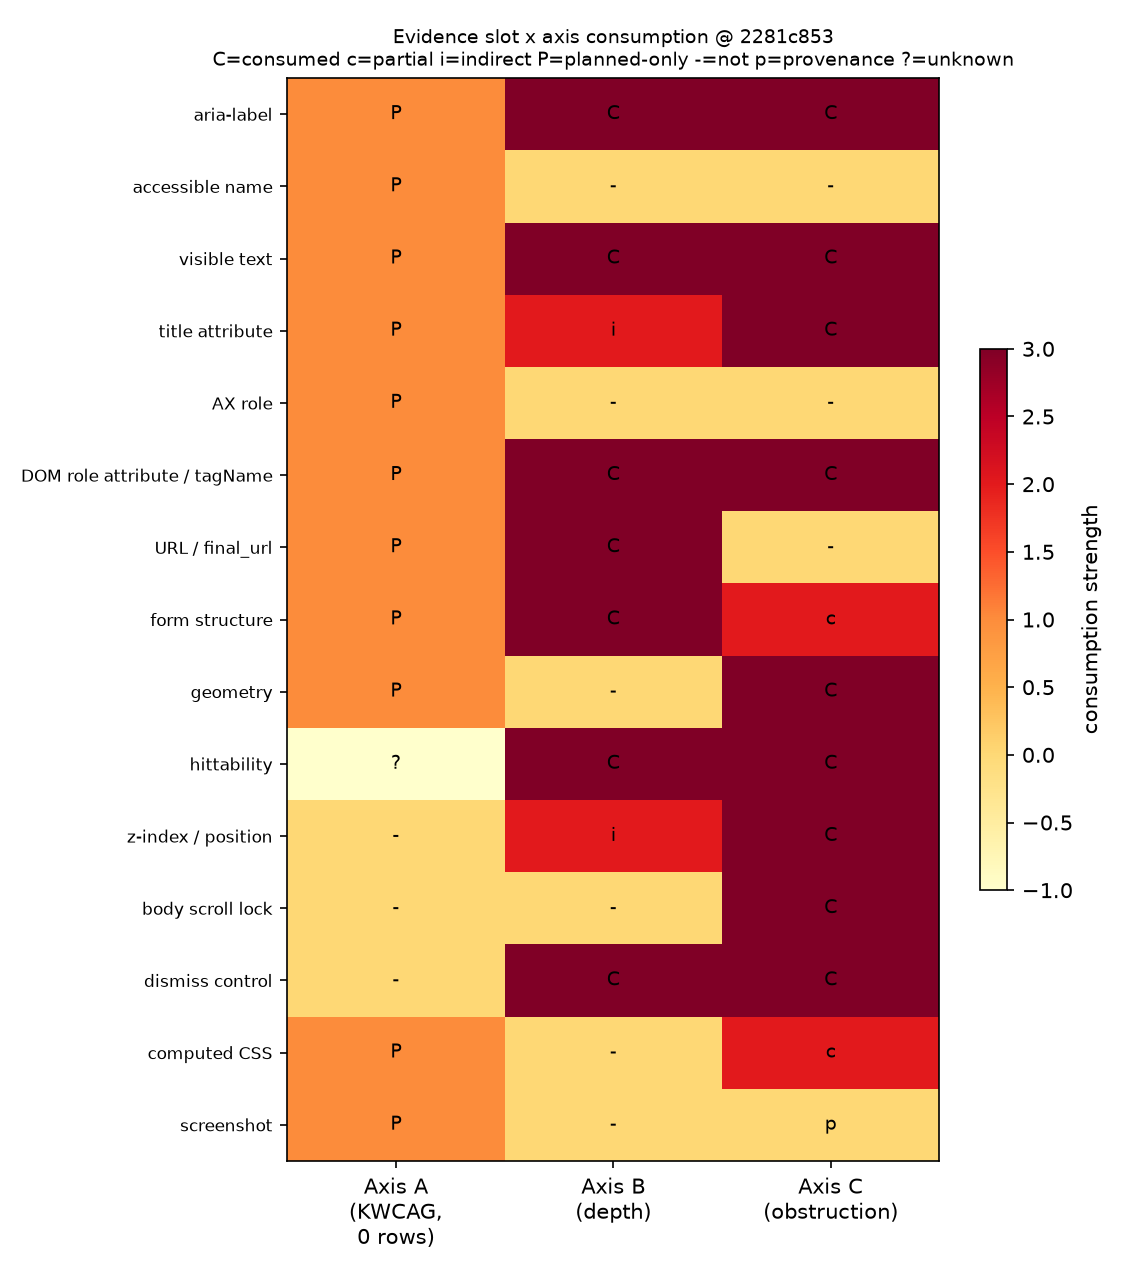

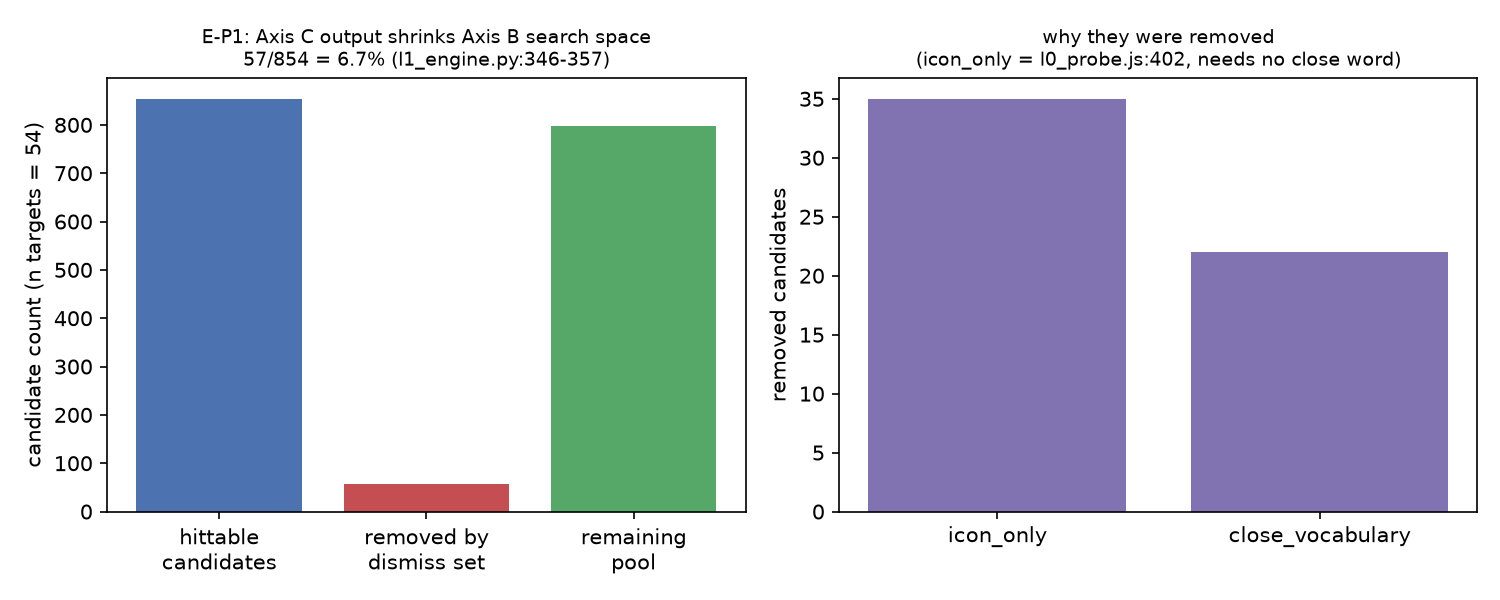

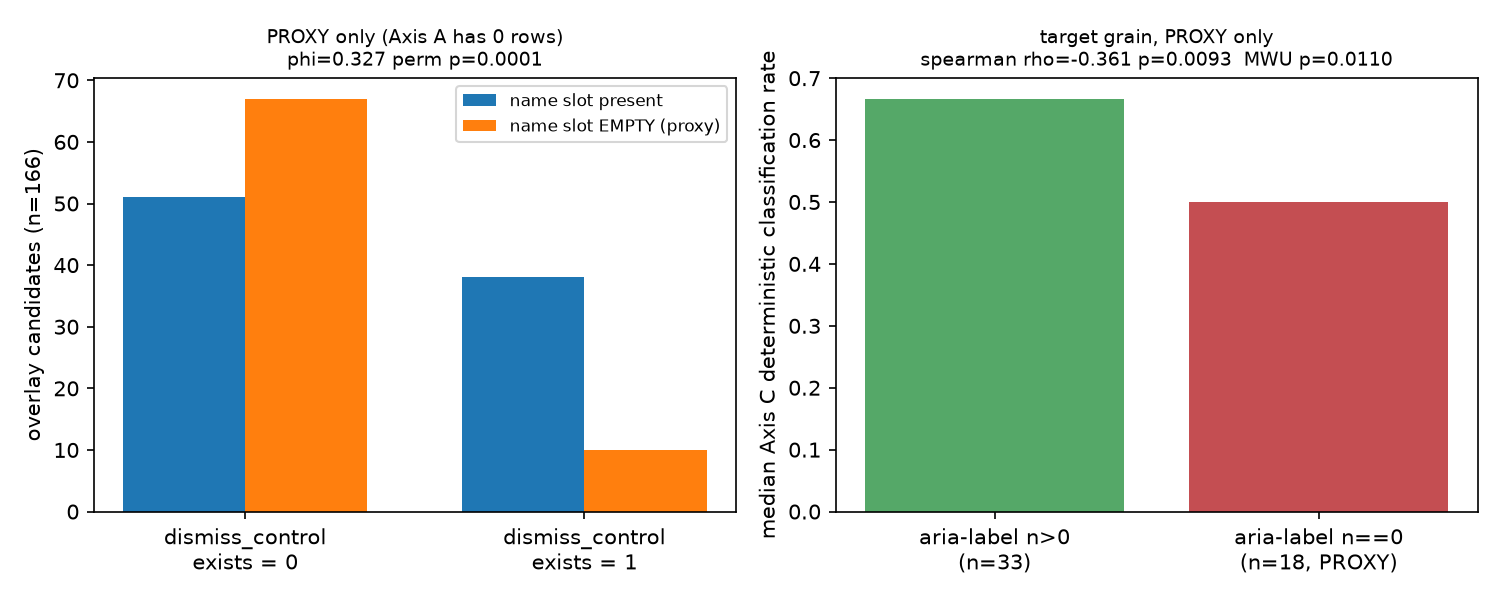

In [11]:
figs = E.make_figures(doc)
for f in figs:
    print(f)
from IPython.display import Image, display
for f in figs:
    display(Image(filename=f))